# FarmTech Solutions — Fase 5
## Entrega 1 — Rendimento agrícola
**Aluno:** Jeliel Cardoso · **RM:** 572665

O sufixo pbl_fase4.ipynb foi mantido conforme a exigência literal do enunciado da Fase 5.
Este relatório explora o arquivo oficial, identifica grupos e outliers e compara cinco regressões.
Para reproduzir: abrir o projeto completo, selecionar o kernel das dependências da Fase 5 e
executar as células em ordem, ou usar run_entrega1_ml.bat. Os scripts auxiliares estão incluídos.

## 1. Origem e qualidade
O CSV original do portal é preservado sem alterar valores. O arquivo origem_dataset.json registra
a procedência informada pelo aluno e o SHA-256. A leitura mapeia os cabeçalhos originais em inglês.

**Unidades:** o enunciado informa t/ha e mm/dia, mas Yield chega a 203399 e precipitação está na casa
dos milhares. Sem dicionário adicional, não aplicamos conversão arbitrária. Métricas e previsões
são apresentadas na **unidade original de Yield**. O nome interno rendimento_t_ha é legado do
projeto e não confirma a escala física. A periodicidade e as unidades devem ser confirmadas na fonte.

Linhas inválidas e duplicatas completas são contabilizadas e removidas antes da divisão.

In [10]:
# Localiza o projeto a partir da raiz, da Fase 5 ou da pasta do notebook.
from pathlib import Path
import sys, inspect, json, joblib
import pandas as pd
from IPython.display import Image, display
BASE_DIR = None
for raiz in [Path.cwd(), *Path.cwd().parents]:
    for candidata in [raiz, raiz / "entrega1_ml", raiz / "pbl/fase5/entrega1_ml"]:
        if (candidata / "scripts/dataset.py").exists():
            BASE_DIR = candidata
            break
    if BASE_DIR is not None:
        break
if BASE_DIR is None:
    raise FileNotFoundError("Abra o notebook dentro do projeto completo.")
sys.path.insert(0, str(BASE_DIR / "scripts"))
from dataset import carregar_dados, ler_csv, NUMERICAS, ALVO
from executar_analise import executar_pipeline, criar_preprocessador, treinar_modelos
OUTPUT_DIR, MODELS_DIR = BASE_DIR / "outputs", BASE_DIR / "models"
df_raw, _, qualidade = ler_csv()
df = carregar_dados()
print("Origem:", df.attrs["origem"])
print("Qualidade:", qualidade)
display(df_raw.head())

Origem: {'tipo': 'portal_fiap', 'descricao': 'Arquivo baixado do portal FIAP e fornecido pelo aluno', 'arquivo_original': 'crop_yield.csv', 'importado_em_utc': '2026-09-09T00:40:54.388487+00:00', 'sha256': '07b3335f497e08e705b5835ee334426ac16cb24732c1bfaa994254d39f771b1b', 'linhas_originais': 156, 'linhas_validas_unicas': 156}
Qualidade: {'linhas_originais': 156, 'linhas_invalidas_removidas': 0, 'duplicatas_removidas': 0, 'linhas_analisadas': 156, 'ausentes_originais': {'Crop': 0, 'Precipitation (mm day-1)': 0, 'Specific Humidity at 2 Meters (g/kg)': 0, 'Relative Humidity at 2 Meters (%)': 0, 'Temperature at 2 Meters (C)': 0, 'Yield': 0}, 'mapeamento_colunas': {'Crop': 'cultura', 'Precipitation (mm day-1)': 'precipitacao_mm_dia', 'Specific Humidity at 2 Meters (g/kg)': 'umidade_especifica_2m_g_kg', 'Relative Humidity at 2 Meters (%)': 'umidade_relativa_2m_pct', 'Temperature at 2 Meters (C)': 'temperatura_2m_c', 'Yield': 'rendimento_t_ha'}, 'sha256': '07b3335f497e08e705b5835ee334426ac16

,Crop,Precipitation (mm day-1),Specific Humidity at 2 Meters (g/kg),Relative Humidity at 2 Meters (%),Temperature at 2 Meters (C),Yield
0,"Cocoa, beans",2248.92,17.72,83.40,26.01,11560
1,"Cocoa, beans",1938.42,17.54,82.11,26.11,11253
2,"Cocoa, beans",2301.54,17.81,82.79,26.24,9456
3,"Cocoa, beans",2592.35,17.61,85.07,25.56,9321
4,"Cocoa, beans",2344.72,17.61,84.12,25.76,8800


## 2. Análise exploratória
Cultura é categórica. Clima é entrada numérica e Yield é o alvo. Comparar rendimentos absolutos
de culturas diferentes não equivale a comparar eficiência agrícola.

In [11]:
# Tipos, ausentes, estatísticas e distribuição por cultura.
print("Dimensão:", df_raw.shape)
display(pd.DataFrame({"tipo": df_raw.dtypes.astype(str), "ausentes": df_raw.isna().sum()}))
display(df_raw.describe(include="all").T)
display(df.groupby("cultura")[ALVO].agg(["count", "mean", "min", "max"]).round(3))
print("Cenários climáticos distintos:", len(df[NUMERICAS].drop_duplicates()))

Dimensão: (156, 6)


,tipo,ausentes
Crop,str,0
Precipitation (mm day-1),float64,0
Specific Humidity at 2 Meters (g/kg),float64,0
Relative Humidity at 2 Meters (%),float64,0
Temperature at 2 Meters (C),float64,0
Yield,int64,0


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Crop,156,4,"Cocoa, beans",39,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Precipitation (mm day-1),156.0,NaN,NaN,NaN,2486.498974,289.457914,1934.62,2302.99,2424.55,2718.08,3085.79
Specific Humidity at 2 Meters (g/kg),156.0,NaN,NaN,NaN,18.203077,0.293923,17.54,18.03,18.27,18.4,18.7
Relative Humidity at 2 Meters (%),156.0,NaN,NaN,NaN,84.737692,0.996226,82.11,84.12,84.85,85.51,86.1
Temperature at 2 Meters (C),156.0,NaN,NaN,NaN,26.18359,0.26105,25.56,26.02,26.13,26.3,26.81
Yield,156.0,NaN,NaN,NaN,56153.096154,70421.958897,5249.0,8327.75,18871.0,67518.75,203399.0


,count,mean,min,max
cultura,,,,
"Cocoa, beans",39,8883.128,5765,13056
Oil palm fruit,39,175804.692,142425,203399
"Rice, paddy",39,32099.667,24686,42550
"Rubber, natural",39,7824.897,5249,10285


Cenários climáticos distintos: 39


## 3. Preparação e avaliação supervisionada
Os 39 cenários climáticos são repetidos nas quatro culturas. GroupShuffleSplit mantém cada
cenário inteiro no treino ou no teste. São 120 registros de treino e 36 de teste, sem cenário
compartilhado. No treino, GroupKFold com cinco folds seleciona o algoritmo pelo menor RMSE médio.

StandardScaler e OneHotEncoder ficam dentro de cada Pipeline, ajustados apenas no respectivo
treino. O teste é consultado depois da seleção. Os parâmetros dos algoritmos são fixos.
A referência adicional prevê a média de cada cultura calculada somente no treino.

In [12]:
# Implementação reutilizável, comentada e visível no notebook.
print(inspect.getsource(criar_preprocessador))
print(inspect.getsource(treinar_modelos))

def criar_preprocessador() -> ColumnTransformer:
    """Cada pipeline ajusta suas escalas e categorias somente no respectivo treino."""
    return ColumnTransformer([
        ("num", StandardScaler(), NUMERICAS),
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), CATEGORICAS),
    ])

def treinar_modelos(df: pd.DataFrame) -> tuple[pd.DataFrame, Pipeline, pd.DataFrame]:
    X, y = df[NUMERICAS + CATEGORICAS], df[ALVO]
    treino_idx, teste_idx, grupos = separar_dados(df)
    X_train, X_test = X.iloc[treino_idx], X.iloc[teste_idx]
    y_train, y_test = y.iloc[treino_idx], y.iloc[teste_idx]
    grupos_treino = grupos.iloc[treino_idx]
    cv = GroupKFold(n_splits=min(5, grupos_treino.nunique()))
    modelos = {
        "Regressão Linear": LinearRegression(),
        "Ridge": Ridge(alpha=1.0),
        "Random Forest": RandomForestRegressor(n_estimators=350, random_state=SEED, min_samples_leaf=2),
        "Gradient Boosting": GradientBoostingRegressor(random_state=S

In [13]:
# Executa análise, treinamento, gráficos e persistência com o CSV oficial.
resumo = executar_pipeline()
print("Modelo selecionado:", resumo["melhor_modelo"])
print("Avaliação:", resumo["avaliacao"])

Modelo selecionado: Extra Trees
Avaliação: {'criterio_selecao': 'Menor RMSE médio na validação cruzada agrupada, somente no treino', 'folds': 5, 'linhas_treino': 120, 'linhas_teste': 36, 'grupos_treino': 30, 'grupos_teste': 9, 'grupos_em_comum': 0, 'baseline_teste': {'MAE': 4554.163888888887, 'MSE': 49639773.00675922, 'RMSE': 7045.549872562057, 'R2': 0.9904278876965359}, 'culturas_ausentes_no_treino': []}


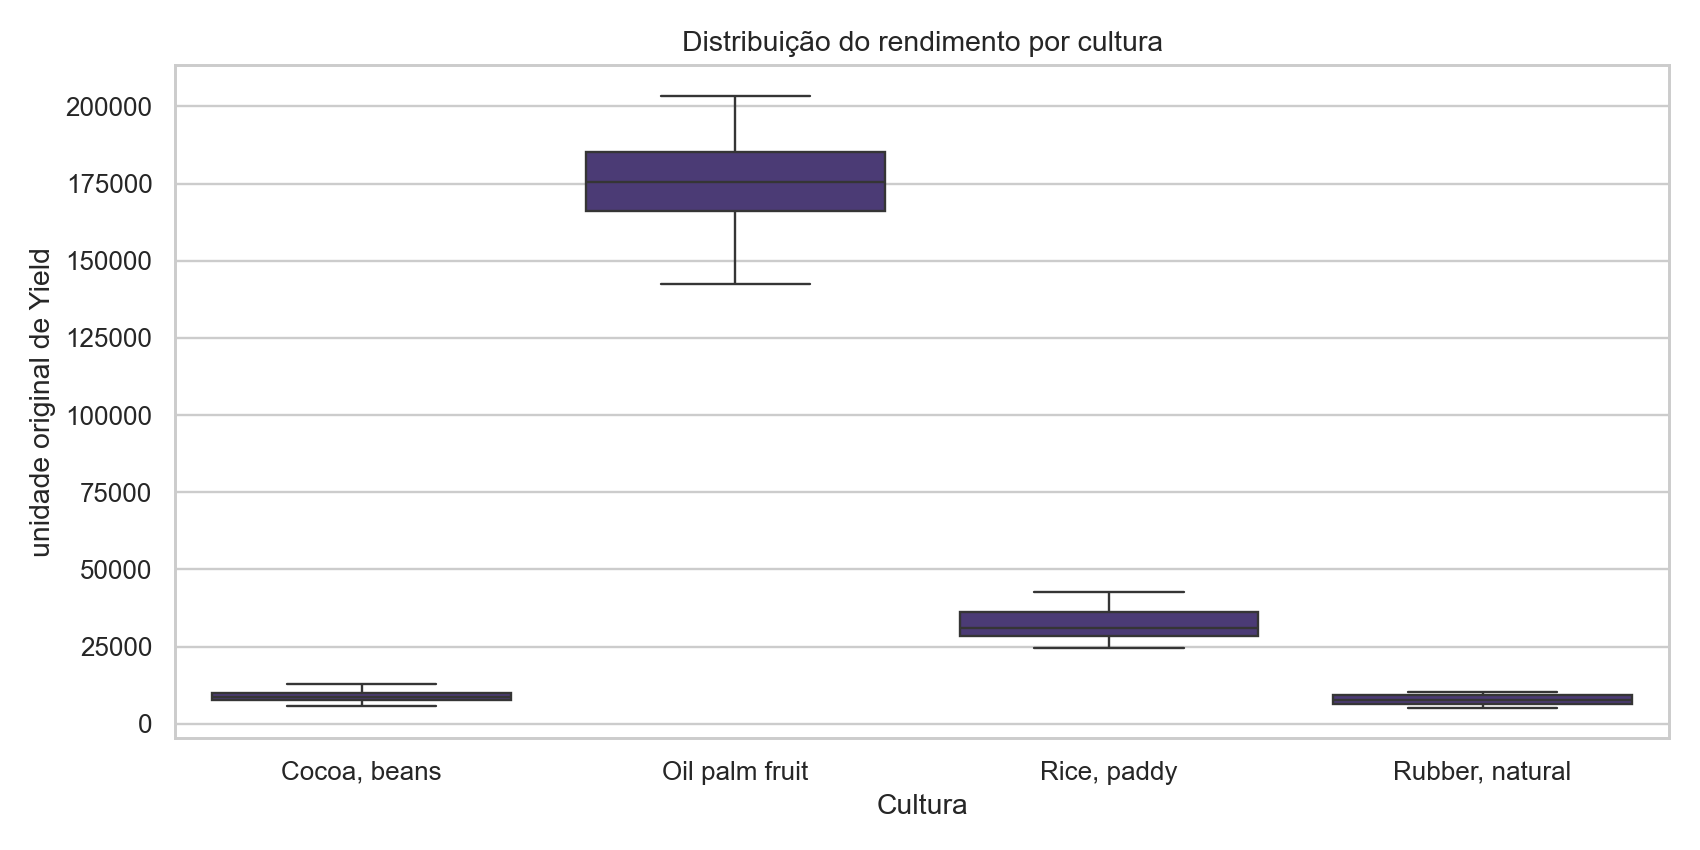

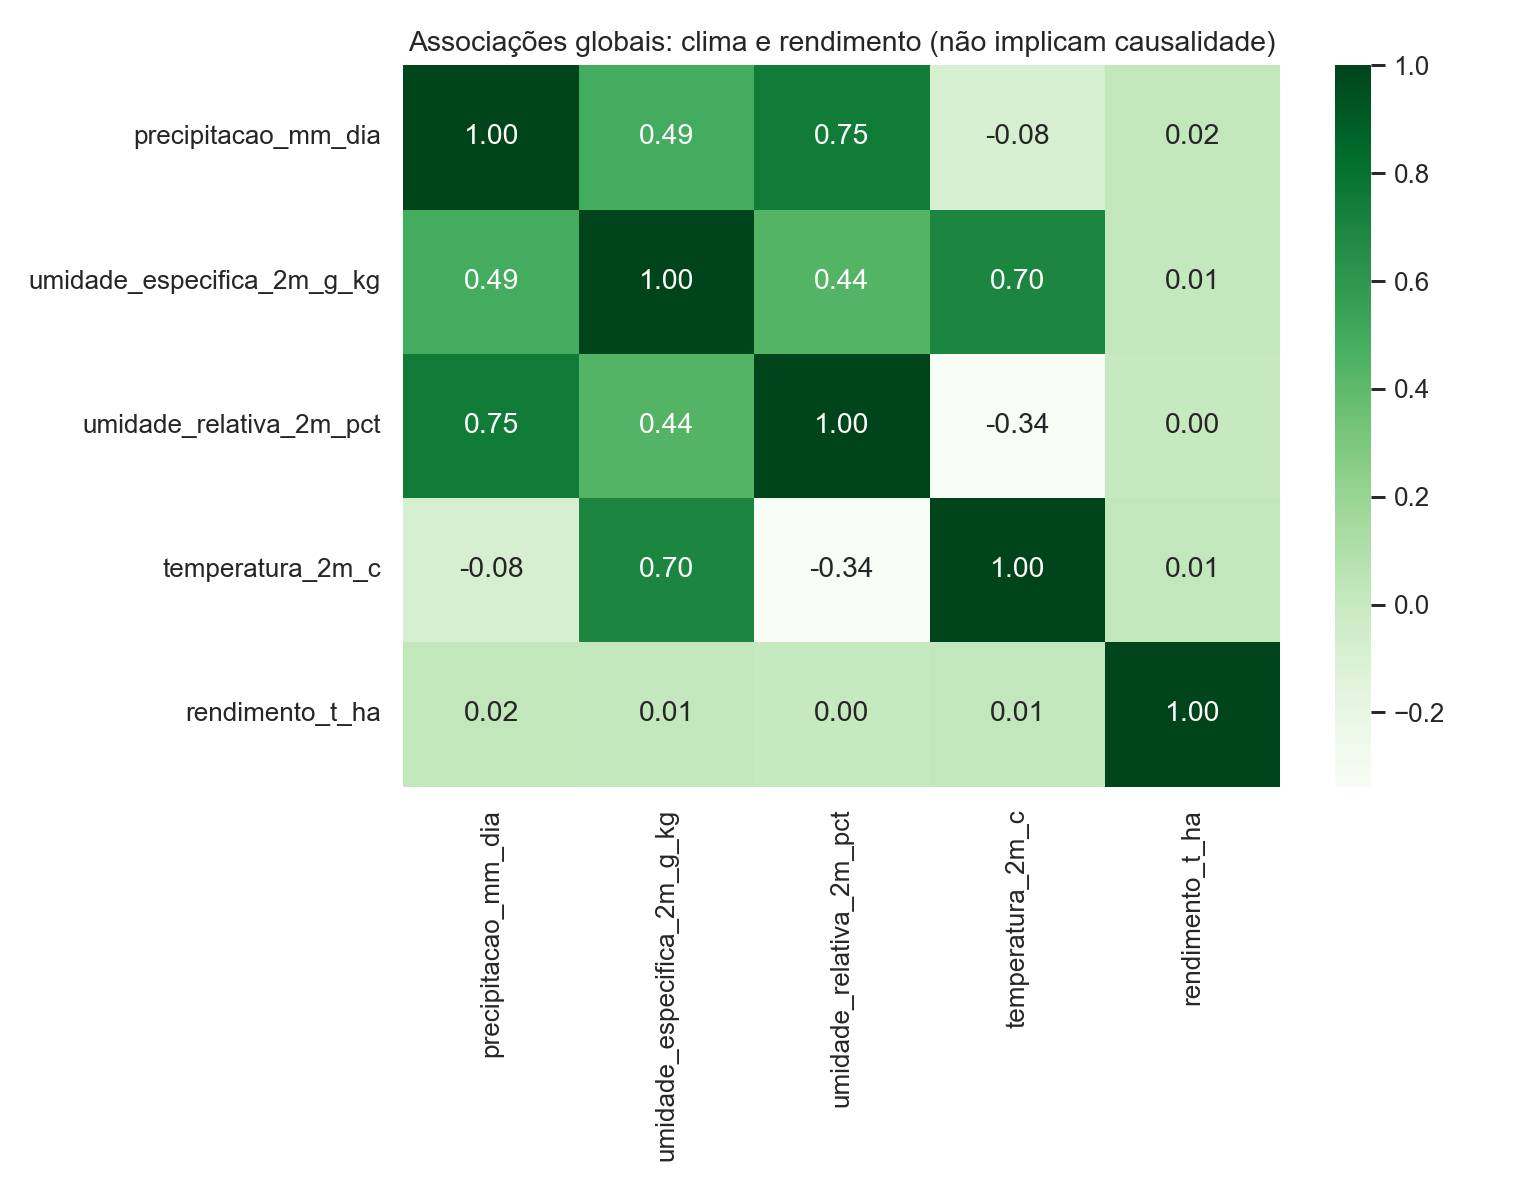

In [14]:
# Gráficos da exploração gerados nesta execução.
display(Image(filename=str(OUTPUT_DIR / "distribuicao_rendimento_por_cultura.png")))
display(Image(filename=str(OUTPUT_DIR / "correlacao_variaveis.png")))

**Achados exploratórios:** 156 registros, 39 por cultura (cacau, palma, arroz e borracha natural),
sem ausentes nem duplicatas completas. Palma tem uma escala de rendimento muito superior.
Por isso, até a média por cultura pode apresentar R² global alto. As correlações são associações
descritivas e não comprovam causalidade; a base não identifica datas nem talhões.

## 4. Clusterização, tendências e outliers
KMeans compara k de 2 a 6 pelo silhouette. Usa clima padronizado e cultura codificada,
**sem usar Yield**. O rendimento é relacionado aos grupos depois. PCA serve à visualização.
Isolation Forest usa contamination=0.05: a proporção de aproximadamente 5% é configurada,
não descoberta. Os candidatos a outlier não são removidos do treinamento.

resumo_clusters.csv


,cluster,registros,rendimento_medio,precipitacao_media,temperatura_media
0,0,44,57453.000,2359.025,26.481
1,1,68,56736.544,2733.518,26.119
2,2,44,53951.500,2232.217,25.986


composicao_clusters.csv


,cluster,"Cocoa, beans",Oil palm fruit,"Rice, paddy","Rubber, natural"
0,0,11,11,11,11
1,1,17,17,17,17
2,2,11,11,11,11


tendencias_por_cultura_cluster.csv


,cluster,cultura,registros,rendimento_medio,precipitacao_media,temperatura_media
0,0,"Cocoa, beans",11,8819.273,2359.025,26.481
1,0,Oil palm fruit,11,178607.545,2359.025,26.481
2,0,"Rice, paddy",11,35576.545,2359.025,26.481
3,0,"Rubber, natural",11,6808.636,2359.025,26.481
4,1,"Cocoa, beans",17,8947.588,2733.518,26.119
5,1,Oil palm fruit,17,177074.176,2733.518,26.119
6,1,"Rice, paddy",17,33147.941,2733.518,26.119
7,1,"Rubber, natural",17,7776.471,2733.518,26.119
8,2,"Cocoa, beans",11,8847.364,2232.217,25.986
9,2,Oil palm fruit,11,171039.909,2232.217,25.986


Silhouette: {'2': 0.3152531494555132, '3': 0.32643780662434674, '4': 0.3068298389791961, '5': 0.28504827492649587, '6': 0.27126707687512364}
Variância explicada pelo PCA: 0.7868566383957836


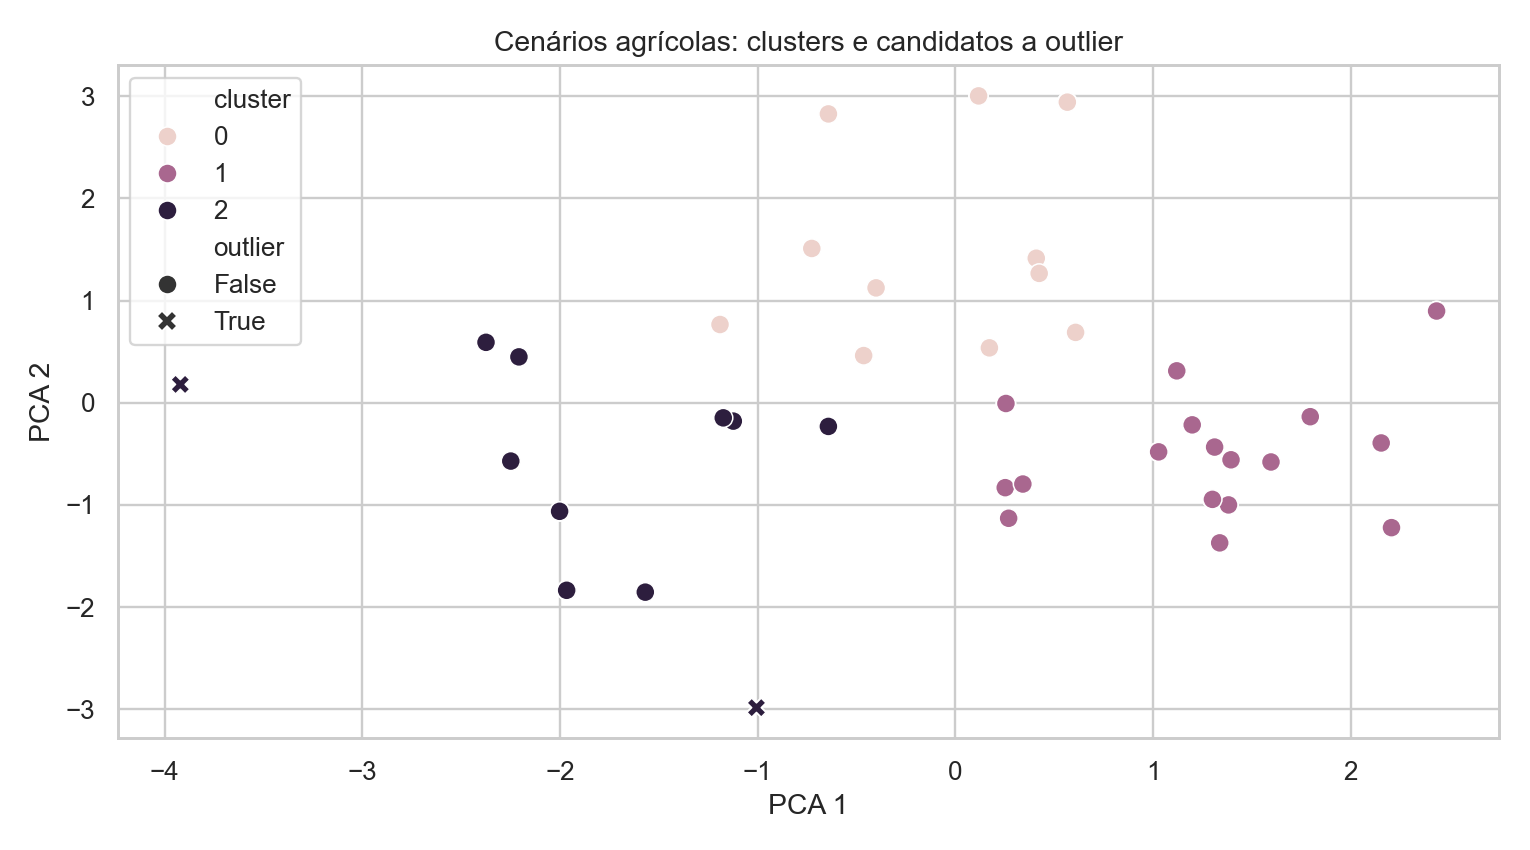

,cultura,precipitacao_mm_dia,umidade_especifica_2m_g_kg,umidade_relativa_2m_pct,temperatura_2m_c,rendimento_t_ha,cluster,outlier,score_anomalia,pca_1,pca_2
0,"Rubber, natural",1938.42,17.54,82.11,26.11,9223,2,True,-0.031148,-3.921371,0.179225
1,"Rice, paddy",2592.35,17.61,85.07,25.56,25187,2,True,-0.022758,-1.006629,-2.983476
2,Oil palm fruit,1938.42,17.54,82.11,26.11,201436,2,True,-0.020965,-3.921371,0.179225
3,"Cocoa, beans",2592.35,17.61,85.07,25.56,9321,2,True,-0.016269,-1.006629,-2.983476
4,"Rice, paddy",1938.42,17.54,82.11,26.11,27619,2,True,-0.013861,-3.921371,0.179225
5,"Cocoa, beans",1938.42,17.54,82.11,26.11,11253,2,True,-0.010747,-3.921371,0.179225
6,"Rubber, natural",2592.35,17.61,85.07,25.56,9718,2,True,-0.003317,-1.006629,-2.983476
7,Oil palm fruit,2592.35,17.61,85.07,25.56,181826,2,True,-0.002357,-1.006629,-2.983476


In [15]:
# Grupos, composição por cultura e rendimento dentro de cada cultura.
for arquivo in ["resumo_clusters.csv", "composicao_clusters.csv", "tendencias_por_cultura_cluster.csv"]:
    print(arquivo)
    display(pd.read_csv(OUTPUT_DIR / arquivo).round(3))
print("Silhouette:", resumo["silhouette_scores"])
print("Variância explicada pelo PCA:", resumo["pca_variancia_explicada"])
display(Image(filename=str(OUTPUT_DIR / "cluster_pca_outliers.png")))
display(pd.read_csv(OUTPUT_DIR / "exemplos_outliers.csv"))

**Interpretação dos grupos:** k=3 tem o melhor silhouette, aproximadamente 0,3264, uma separação
moderada. Grupos 0, 1 e 2 têm 44, 68 e 44 registros, com as quatro culturas igualmente representadas
em cada grupo. O grupo 1 tem maior precipitação média (2733,52); o 0 maior temperatura (26,48 °C).
Arroz tem rendimento médio de 35576,55 no grupo 0 e 27002,73 no 2. Borracha apresenta o padrão
inverso: 6808,64 e 8916,00. Não há um grupo universalmente mais produtivo para todas as culturas.

Os oito outliers representam dois cenários repetidos em quatro culturas. Um tem umidade específica
17,54 e relativa 82,11%; outro tem a menor temperatura do conjunto, 25,56 °C. São extremos
relativos à amostra, não prova de seca, falha do sensor ou dano agronômico.

## 5. Cinco algoritmos e métricas
Regressão Linear, Ridge (linear regularizada), Random Forest, Gradient Boosting e Extra Trees.
A tabela é ordenada pelo RMSE médio de validação cruzada, e não pelo teste.

MAE mede erro absoluto médio; MSE erro quadrático; RMSE volta à escala original do alvo.
R² mede desempenho relativo à média e pode ser negativo. **R² não é percentual de acerto.**
MAE/RMSE usam a unidade original de Yield; MSE usa essa unidade ao quadrado.

,modelo,CV_RMSE_medio,CV_RMSE_desvio,MAE,MSE,RMSE,R2,selecionado_por_cv
0,Extra Trees,7583.2961,2156.7269,3863.3939,3.928900e+07,6268.0939,0.9924,True
1,Random Forest,7871.4879,2166.1371,3818.1386,4.360186e+07,6603.1708,0.9916,False
2,Regressão Linear,8211.1402,1231.8112,4563.3521,4.586990e+07,6772.7322,0.9912,False
3,Ridge,8608.3851,1318.2845,5066.9134,6.270726e+07,7918.7914,0.9879,False
4,Gradient Boosting,9269.6520,3665.9576,3949.8080,4.491721e+07,6702.0303,0.9913,False


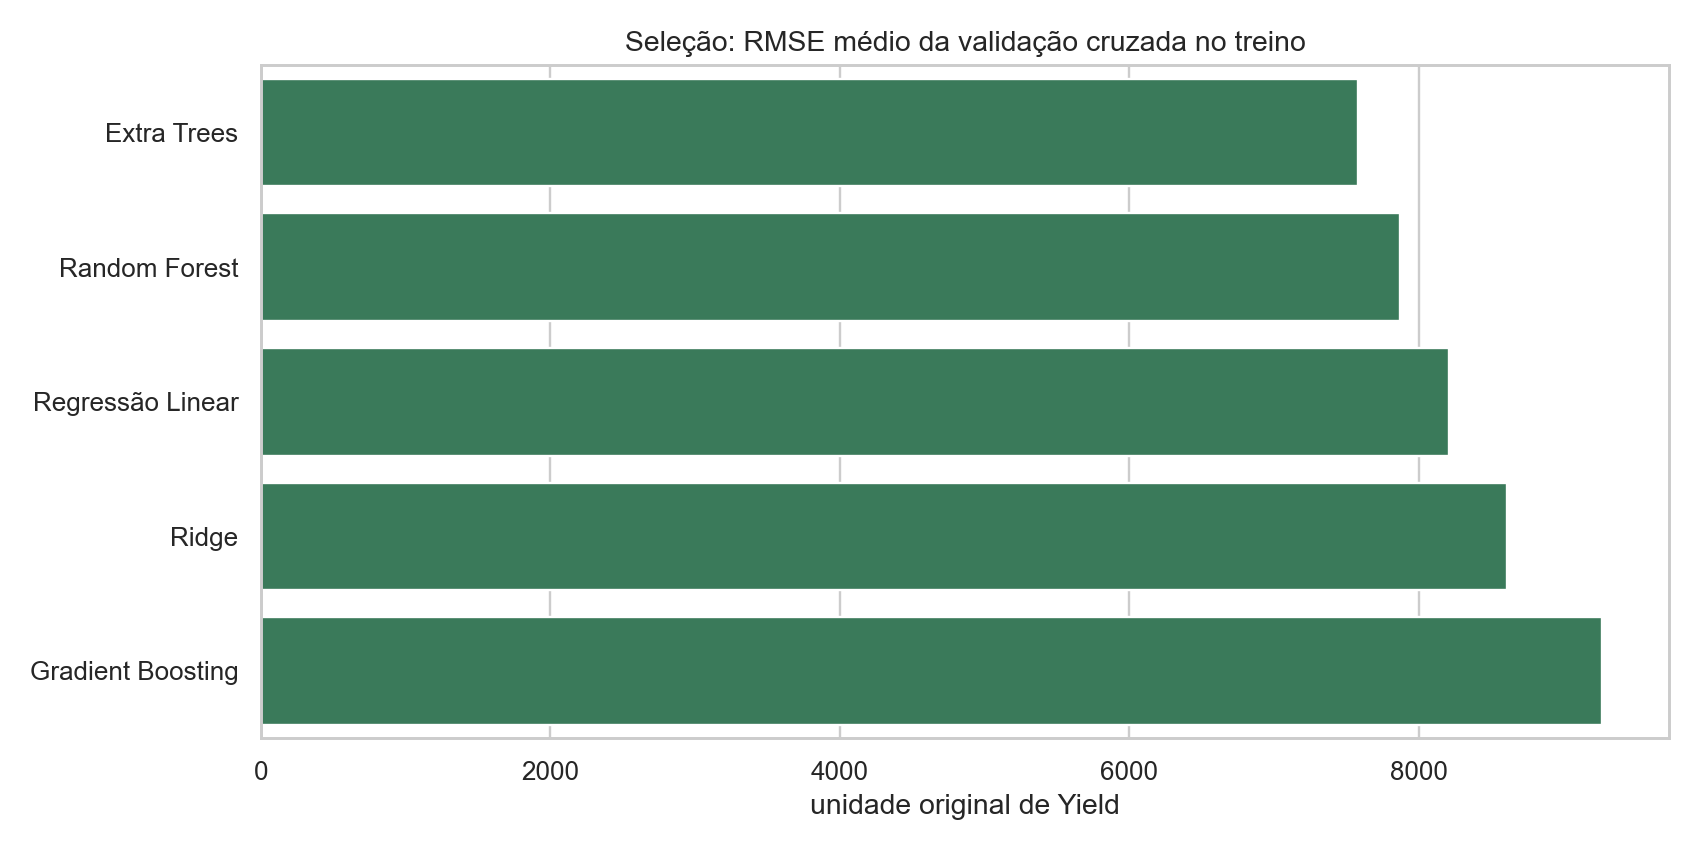

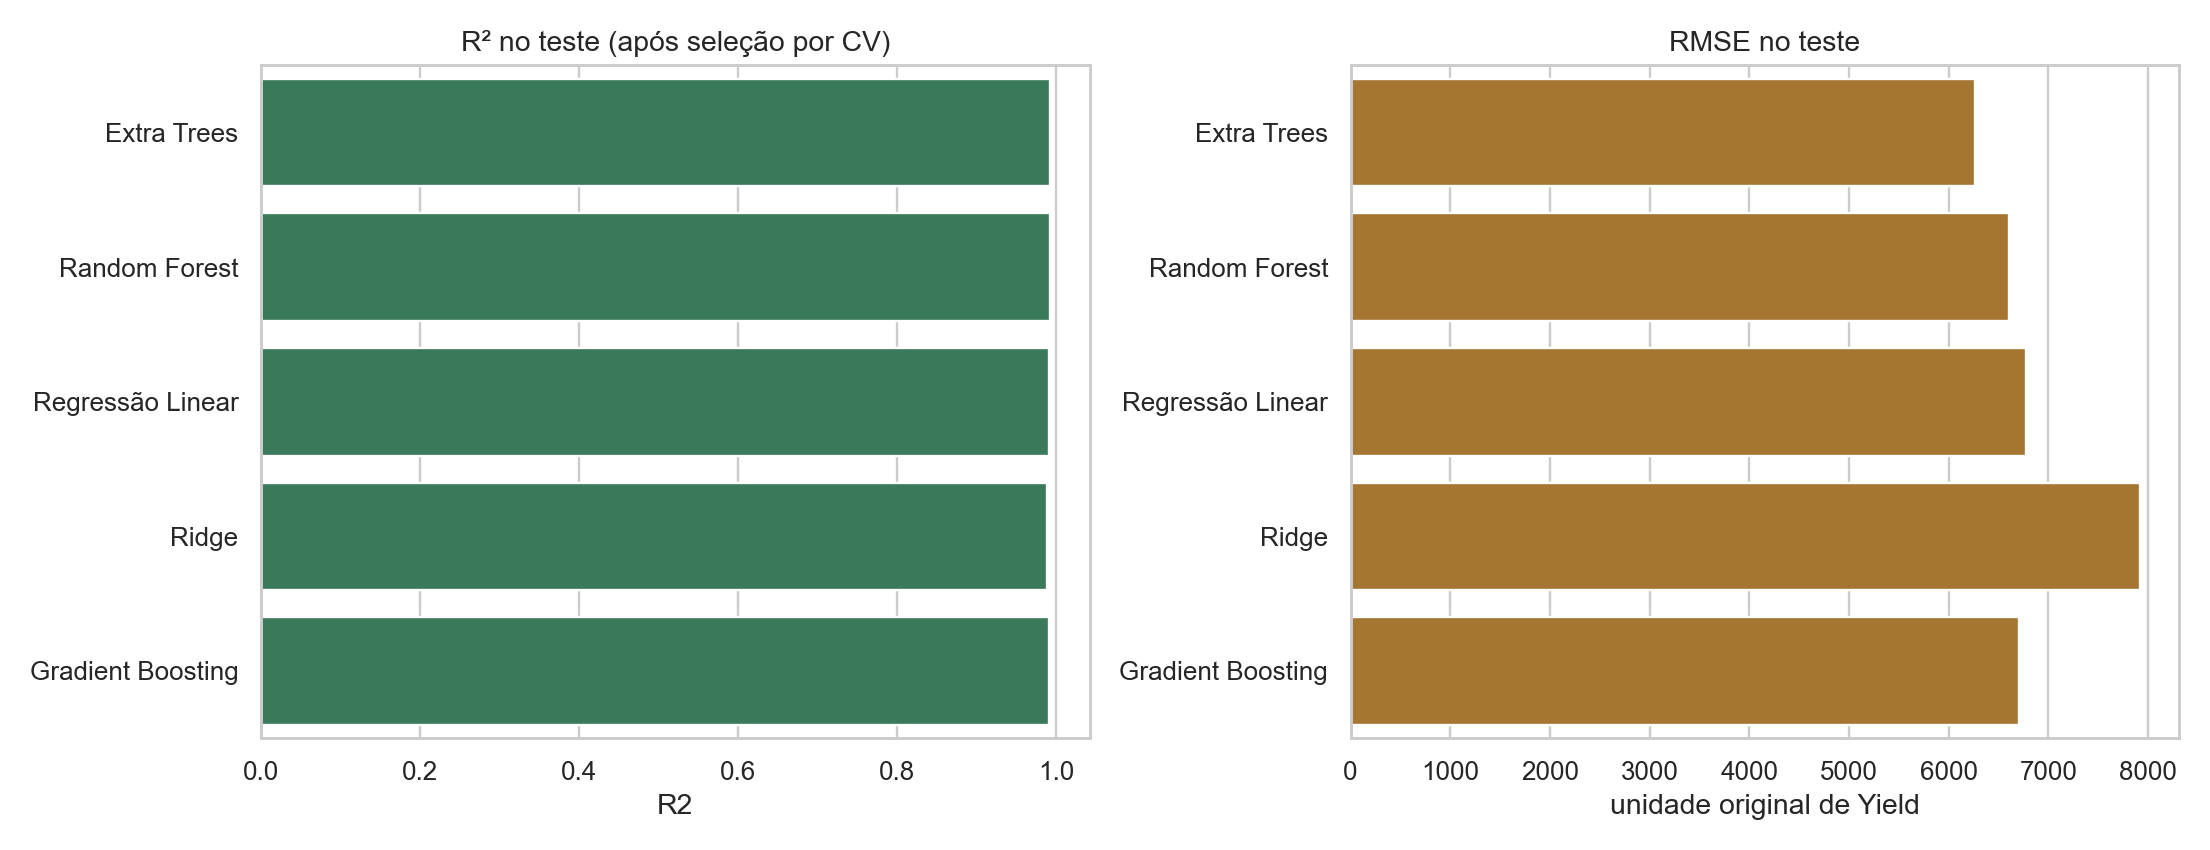

In [16]:
# Compara a seleção por CV e o desempenho no teste reservado.
metricas = pd.read_csv(OUTPUT_DIR / "metricas_modelos.csv")
display(metricas[["modelo", "CV_RMSE_medio", "CV_RMSE_desvio", "MAE", "MSE", "RMSE", "R2", "selecionado_por_cv"]].round(4))
display(Image(filename=str(OUTPUT_DIR / "comparacao_validacao_cruzada.png")))
display(Image(filename=str(OUTPUT_DIR / "comparacao_modelos_r2_rmse.png")))

,modelo,MAE,MSE,RMSE,R2
0,Média por cultura (treino),4554.1639,4.963977e+07,7045.5499,0.9904


,modelo,cultura,registros_teste,MAE,MSE,RMSE,R2
16,Extra Trees,"Cocoa, beans",9,1368.4596,2.862278e+06,1691.8268,-0.2861
17,Extra Trees,Oil palm fruit,9,10118.9365,1.387216e+08,11778.0149,-0.2452
18,Extra Trees,"Rice, paddy",9,2843.7380,1.340391e+07,3661.1355,0.4364
19,Extra Trees,"Rubber, natural",9,1122.4416,2.168176e+06,1472.4727,-0.5336
20,Média por cultura (treino),"Cocoa, beans",9,1419.3000,3.059134e+06,1749.0381,-0.3746
21,Média por cultura (treino),Oil palm fruit,9,10568.0741,1.643206e+08,12818.7613,-0.4749
22,Média por cultura (treino),"Rice, paddy",9,4886.9815,2.900593e+07,5385.7154,-0.2196
23,Média por cultura (treino),"Rubber, natural",9,1342.3000,2.173386e+06,1474.2407,-0.5373


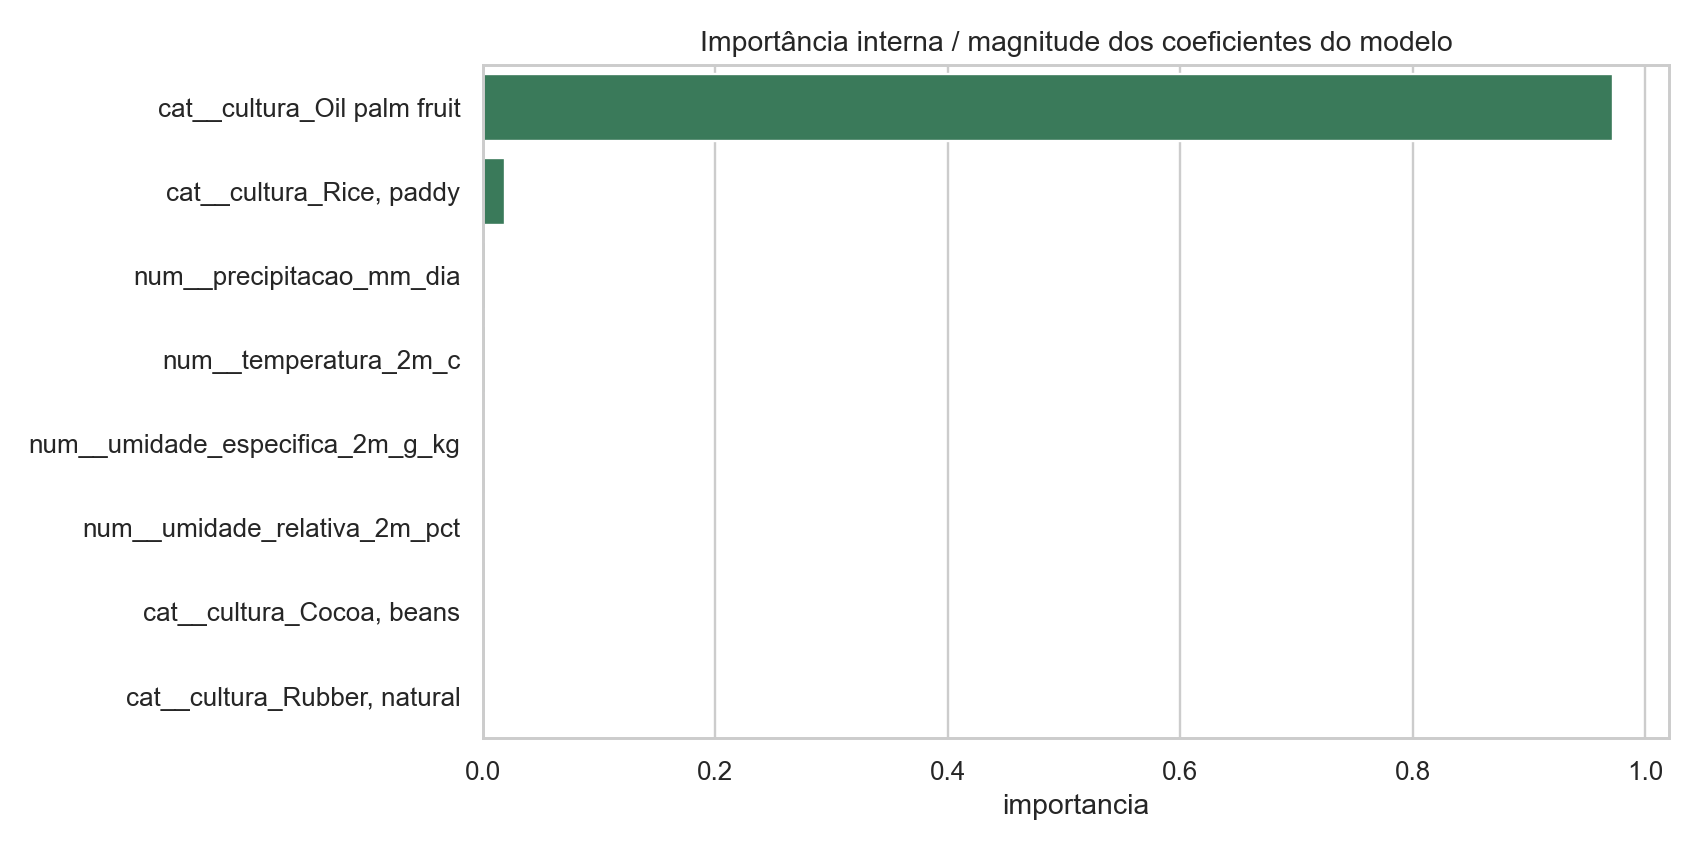

In [17]:
# Avaliação contra referência simples e separadamente por cultura.
display(pd.read_csv(OUTPUT_DIR / "metricas_baseline.csv").round(4))
por_cultura = pd.read_csv(OUTPUT_DIR / "metricas_por_cultura.csv")
display(por_cultura[por_cultura.modelo.isin([resumo["melhor_modelo"], "Média por cultura (treino)"])].round(4))
display(Image(filename=str(OUTPUT_DIR / "importancia_variaveis.png")))

**Resultado:** Extra Trees selecionado com RMSE médio de CV 7583.30. No teste: MAE 3863.39, RMSE 6268.09 e R² 0.9924. A média por cultura teve RMSE 7045.55 e R² 0.9904; a redução de RMSE foi 11.03%. No Extra Trees, só arroz tem R² por cultura positivo (aproximadamente 0,436). As outras três culturas têm R² negativo, apesar do R² global alto. Importância interna não é efeito causal; coeficientes lineares também não equivalem às importâncias de árvores.

## 6. Previsão para um cenário de arroz
O pipeline salvo foi selecionado por CV e ajustado apenas ao treino. As entradas abaixo estão
dentro das faixas observadas. A saída é mantida na unidade original do CSV.

In [18]:
# Célula curta para execução ao vivo no vídeo.
modelo = joblib.load(MODELS_DIR / "melhor_modelo_rendimento.joblib")
cenario = pd.DataFrame([{
    "cultura": "Rice, paddy", "precipitacao_mm_dia": 2450.0,
    "umidade_especifica_2m_g_kg": 18.2, "umidade_relativa_2m_pct": 84.7,
    "temperatura_2m_c": 26.2,
}])
cenario["rendimento_previsto_unidade_original"] = modelo.predict(cenario).round(3)
display(cenario)

,cultura,precipitacao_mm_dia,umidade_especifica_2m_g_kg,umidade_relativa_2m_pct,temperatura_2m_c,rendimento_previsto_unidade_original
0,"Rice, paddy",2450.0,18.2,84.7,26.2,30735.198


## 7. Conclusões
**Pontos fortes:** base oficial rastreável, pipeline reproduzível, cinco algoritmos,
seleção por CV, cenários separados, baseline, métricas por cultura e outliers concretos.

**Limitações:** apenas 39 cenários, ausência de datas/talhões/manejo, escala e periodicidade
a confirmar na fonte, grupos moderadamente separados, proporção de outliers definida a priori
e forte influência da diferença entre culturas no R² global. Cada cultura tem apenas nove
observações no teste. A avaliação não demonstra generalização temporal para uma safra futura.

O resultado é um protótipo educacional. Próximos passos: confirmar unidades, incluir variáveis
de manejo e identificação temporal/espacial e validar em safras independentes.